In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [3]:
print(iris.feature_names)

print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [6]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
pred = knn.predict(X_test)

acc = accuracy_score(y_test, pred)

print("KNN Accuracy =", acc)

KNN Accuracy = 1.0


In [8]:
cm = confusion_matrix(y_test, pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [9]:
for k in range(1,11):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train, y_train)

    pred_k = model.predict(X_test)

    acc_k = accuracy_score(
        y_test,
        pred_k
    )

    print(
        "K =", k,
        "Accuracy =", acc_k
    )

K = 1 Accuracy = 1.0
K = 2 Accuracy = 1.0
K = 3 Accuracy = 1.0
K = 4 Accuracy = 1.0
K = 5 Accuracy = 1.0
K = 6 Accuracy = 1.0
K = 7 Accuracy = 1.0
K = 8 Accuracy = 1.0
K = 9 Accuracy = 1.0
K = 10 Accuracy = 1.0


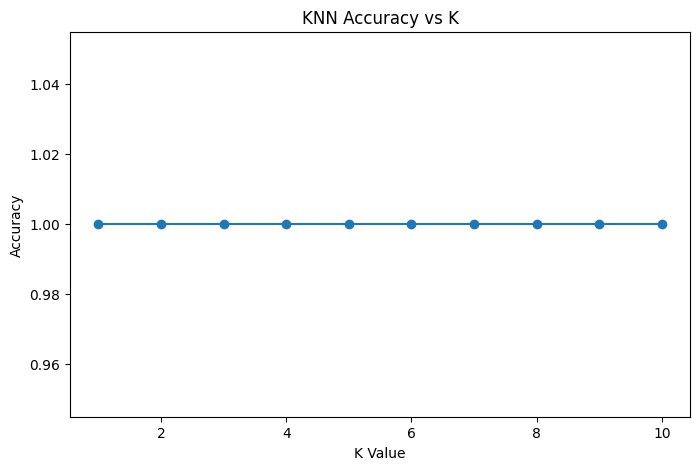

In [10]:
k_values = []
accuracies = []

for k in range(1,11):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train, y_train)

    pred_k = model.predict(X_test)

    acc_k = accuracy_score(
        y_test,
        pred_k
    )

    k_values.append(k)

    accuracies.append(acc_k)

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")

plt.show()

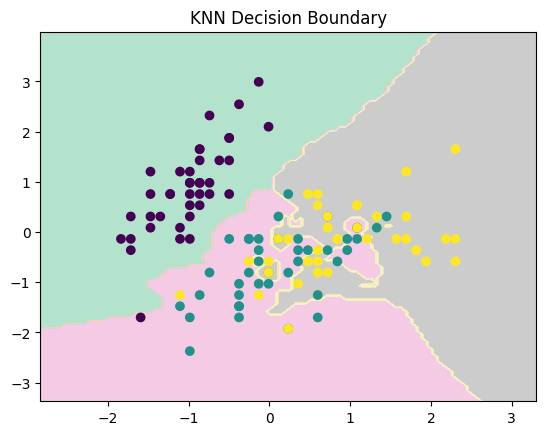

In [11]:
from sklearn.inspection import DecisionBoundaryDisplay

X2 = iris.data[:, :2]
y2 = iris.target

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

knn2 = KNeighborsClassifier(n_neighbors=3)

knn2.fit(X_train2, y_train2)

DecisionBoundaryDisplay.from_estimator(
    knn2,
    X_train2,
    response_method="predict",
    cmap=plt.cm.Pastel2,
)

plt.scatter(
    X_train2[:,0],
    X_train2[:,1],
    c=y_train2
)

plt.title("KNN Decision Boundary")
plt.show()